# Analyzing weekdays repr in GPT-2 from Engels et al.



## Setup

In [1]:
# Notebook setup
%cd /home/can/feature_zoo/
%load_ext autoreload
%autoreload 2

/home/can/feature_zoo


In [2]:
# Load the significant sae feature indices identified by Engels et al.

import json

fname = "exp/weekdays/temporal_clusters.json"
with open(fname, "r") as f:
    clusters = json.load(f)["clusters"]

clusters

{'days_of_week': {'cluster_id': 138,
  'sae_neuron_indices': [2592,
   4445,
   4663,
   4733,
   6531,
   8179,
   9566,
   20927,
   24185],
  'description': 'SAE neurons representing days of the week (circular structure)',
  'num_neurons': 9},
 'months': {'cluster_id': 251,
  'sae_neuron_indices': [3977,
   4140,
   5993,
   7299,
   9104,
   9401,
   10449,
   11196,
   12661,
   14715,
   17068,
   17528,
   19589,
   21033,
   22043,
   23304],
  'description': 'SAE neurons representing months (circular structure)',
  'num_neurons': 16},
 'years': {'cluster_id': 212,
  'sae_neuron_indices': [1052,
   2753,
   4427,
   6382,
   8314,
   9576,
   9606,
   13551,
   19734,
   20349],
  'description': 'SAE neurons representing years (spiral structure)',
  'num_neurons': 10}}

In [3]:
# Select weekday feature indices

days_idxs = clusters["days_of_week"]["sae_neuron_indices"]
days_idxs

[2592, 4445, 4663, 4733, 6531, 8179, 9566, 20927, 24185]

In [4]:
# Initialize Experiment config (defines dataset, model, sae)

from src.config import load_config
from src.loading import load_sae

cfg = load_config(overrides=[
    "sae=gpt2_relu",
    "llm=gpt2",
    "data=days_21k"
])

/home/can/feature_zoo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch as th
import numpy as np

# Load SAE
sae = load_sae(cfg)

def to_numpy(t: th.Tensor) -> np.ndarray:
    return t.detach().cpu().float().numpy()

W_dec_SD = to_numpy(sae.Ad.T) # note the transpose --> colspace
W_dec_days_sD = W_dec_SD[days_idxs]

W_enc_SD = to_numpy(sae.Ae) # note no transpose --> rowspace
W_enc_days_sD = W_enc_SD[days_idxs]

# SAE weight-based analysis

## Effective Rank of encoder "reading" subspace and decoder "writing" subspace

Effective rank should be 2 if the days of the week representation is a 2D circle?

Cumulative relative energy per PCA:
PCA 0: 0.6557263135910034
PCA 1: 0.7243295311927795
PCA 2: 0.7765918970108032
PCA 3: 0.8218057751655579
PCA 4: 0.8653000593185425
PCA 5: 0.9033180475234985
PCA 6: 0.9375587701797485
PCA 7: 0.9697102904319763
PCA 8: 1.0

Cumulative relative energy per PCA:
PCA 0: 0.675532341003418
PCA 1: 0.753860354423523
PCA 2: 0.8155248165130615
PCA 3: 0.8657773733139038
PCA 4: 0.9122761487960815
PCA 5: 0.9413783550262451
PCA 6: 0.9692696928977966
PCA 7: 0.9879446029663086
PCA 8: 1.0000001192092896



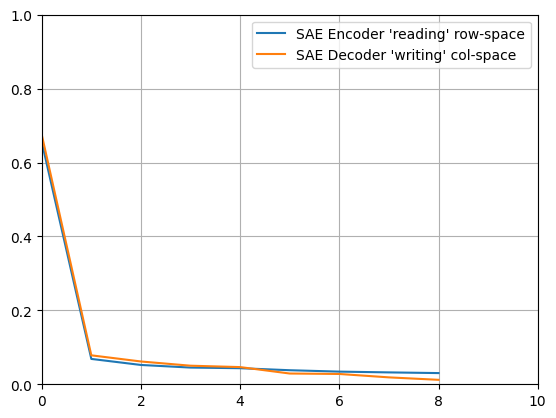

In [6]:
import torch as th
import matplotlib.pyplot as plt
from typing import List
import numpy as np

# Effective dimensionality
def plot_relative_energies(list_act_BD: List[np.ndarray], legend_labels: List[str]) -> None:
    for act_BD, legend_label in zip(list_act_BD, legend_labels):
        U_sr, S_sr, Vt_sr = np.linalg.svd(act_BD, full_matrices=False)
        energy_sr = S_sr**2 / (S_sr**2).sum()
        plt.plot(energy_sr, label=legend_label)

        print("Cumulative relative energy per PCA:")
        energy_cumsum = np.cumsum(energy_sr, axis=0)[:10]
        for i, e in enumerate(energy_cumsum):
            print(f'PCA {i}: {e}')
        print()

    plt.xlim(0, 10)
    plt.ylim(0,1)
    plt.grid()
    plt.legend()



plot_relative_energies(
    [W_enc_days_sD, W_dec_days_sD], ["SAE Encoder 'reading' row-space", "SAE Decoder 'writing' col-space"]
)

# Activation-based analysis

In [7]:
# Load activation data

from src.cache_llm import load_labeled_acts

return_dict = load_labeled_acts(cfg, force_recompute=False)

labels = return_dict["labels"]
llm_BD = to_numpy(return_dict["llm_BD"])
codes_BS = to_numpy(return_dict["codes_BD"])
texts = return_dict["texts"]

TypeError: get_tokenized_texts() missing 1 required positional argument: 'tokenizer'

### PCA on raw, full llm activations

In [ ]:
from sklearn.decomposition import PCA

def plot_pca_2d(
        act_BD: np.ndarray, 
        labels_B: list, 
        num_pca_components: int = 9, 
        return_pca_components: bool = False, 
        min_ax_scale: int = 5
    ) -> None:

    # PCA transform
    assert act_BD.shape[0] >= num_pca_components, "num_pca_components must be bigger than num samples (B) in act_BD."

    pca = PCA(n_components=num_pca_components)
    pca_BD = pca.fit_transform(act_BD)

    print(f"PCA transformed shape: {pca_BD.shape}")
    cumulative_exp_var = np.cumsum(pca.explained_variance_ratio_, axis=-1)
    print("Cumulative Explained Variance:")
    for i, ev in enumerate(cumulative_exp_var):
        print(f"up to incl. PCA {i}: {ev}")

    # PLOT
    unique_labels = list(dict.fromkeys(labels_B))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

    # Tab10 colors for categorical coloring
    tab10_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # Define consecutive PC pairs
    pc_pairs = [(i, i+1) for i in range(num_pca_components - 1)]

    # Create subplot grid
    n_cols = 4
    n_rows = (num_pca_components-1) // n_cols
    if (num_pca_components-1) % n_cols > 0:
        n_rows += 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
    axes = axes.flatten()

    # Plot each consecutive PC pair
    for idx, (pc_x, pc_y) in enumerate(pc_pairs):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Plot each label with different color
        for label in unique_labels:
            # if label.lower() == "sunday":
            #     continue
            mask = [l == label for l in labels_B]
            label_idx = label_to_idx[label]
            color = tab10_colors[label_idx % len(tab10_colors)]
            ax.scatter(pca_BD[mask, pc_x], pca_BD[mask, pc_y],
                    label=label, color=color, alpha=0.8, s=50)

        # Set labels and title
        x_min = min(min(pca_BD[:, pc_x]), -1*min_ax_scale) * 1.1
        x_max = max(max(pca_BD[:, pc_x]), min_ax_scale) * 1.1
        y_min = min(min(pca_BD[:, pc_y]), -1*min_ax_scale) * 1.1
        y_max = max(max(pca_BD[:, pc_y]), min_ax_scale) * 1.1
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel(f'PC {pc_x}', fontsize=12)
        ax.set_ylabel(f'PC {pc_y}', fontsize=12)
        ax.set_title(f'PC{pc_x} vs PC{pc_y}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Add legend to first subplot only
        if idx == 0:
            ax.legend(loc='upper right', fontsize=10)

    # Hide unused subplots
    for idx in range(len(pc_pairs), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    if return_pca_components:
        return pca.components_


def plot_pca_3d(act_BD: th.Tensor, labels_B: list, texts_B: list = None, pca_components: list = [0, 1, 2]) -> None:
    import plotly.graph_objs as go
    
    # PCA transform to 3D
    num_pca_components = max(pca_components) + 1
    pca_3d = PCA(n_components=num_pca_components)
    pca_3d_BD = pca_3d.fit_transform(act_BD)

    print(f"PCA 3D transformed shape: {pca_3d_BD.shape}")
    print(f"Explained variance ratio: {pca_3d.explained_variance_ratio_}")
    print(f"Cumulative explained variance: {pca_3d.explained_variance_ratio_.sum():.4f}")

    # Get unique labels and create label-to-index mapping
    unique_labels_3d = list(dict.fromkeys(labels_B))
    label_to_idx_3d = {label: idx for idx, label in enumerate(unique_labels_3d)}

    # Tab10 colors
    tab10_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # Create customdata for hover information
    if texts_B is not None:
        customdata_3d = list(zip(labels_B, texts_B))
        hovertemplate = "Label: %{customdata[0]}<br>Text: %{customdata[1]}<extra></extra>"
    else:
        customdata_3d = labels_B
        hovertemplate = "Label: %{customdata}<extra></extra>"

    # Create interactive 3D PCA plot
    fig_pca = go.Figure(
        data=[
            go.Scatter3d(
                x=pca_3d_BD[:, pca_components[0]],
                y=pca_3d_BD[:, pca_components[1]],
                z=pca_3d_BD[:, pca_components[2]],
                mode="markers",
                customdata=customdata_3d,
                hovertemplate=hovertemplate,
                marker=dict(
                    size=6,
                    color=[label_to_idx_3d[label] for label in labels_B],
                    colorscale=[[i / (len(unique_labels_3d) - 1) if len(unique_labels_3d) > 1 else 0, 
                                tab10_colors[i % len(tab10_colors)]] 
                               for i in range(len(unique_labels_3d))],
                    opacity=0.8,
                    showscale=True,
                    colorbar=dict(
                        title="Day",
                        tickmode="array",
                        tickvals=list(range(len(unique_labels_3d))),
                        ticktext=unique_labels_3d,
                    ),
                ),
            )
        ]
    )
    fig_pca.update_layout(
        scene=dict(
            xaxis_title=f"PC {pca_components[0]} ({pca_3d.explained_variance_ratio_[pca_components[0]]:.2%})",
            yaxis_title=f"PC {pca_components[1]} ({pca_3d.explained_variance_ratio_[pca_components[1]]:.2%})",
            zaxis_title=f"PC {pca_components[2]} ({pca_3d.explained_variance_ratio_[pca_components[2]]:.2%})"
        ),
        margin=dict(l=0, r=0, b=0, t=30),
        title="PCA 3D Scatter of Day Representations",
        width=900,
        height=700
    )
    fig_pca.show()

In [8]:
llm_BD_norms = np.linalg.norm(llm_BD, axis=-1)
plt.hist(llm_BD_norms, bins=100, log=True);

NameError: name 'llm_BD' is not defined

PCA transformed shape: (21001, 9)
Cumulative Explained Variance:
up to incl. PCA 0: 0.1149546205997467
up to incl. PCA 1: 0.1794237494468689
up to incl. PCA 2: 0.21884578466415405
up to incl. PCA 3: 0.2506754994392395
up to incl. PCA 4: 0.2756551206111908
up to incl. PCA 5: 0.29740217328071594
up to incl. PCA 6: 0.31531086564064026
up to incl. PCA 7: 0.33132314682006836
up to incl. PCA 8: 0.3452930152416229


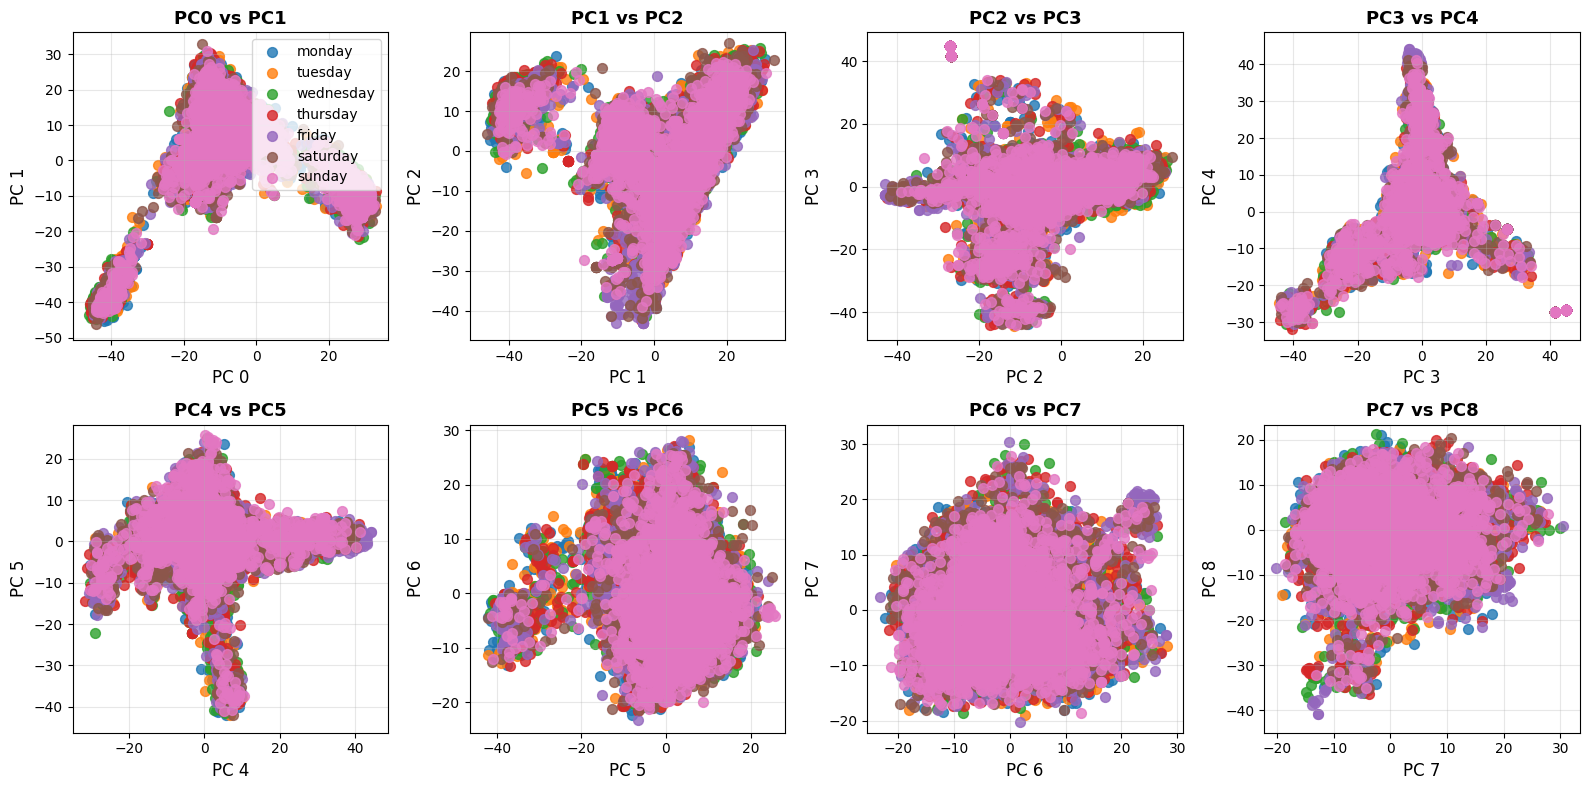

In [ ]:
plot_pca_2d(llm_BD, labels)

### PCA of Projection of LLM activaitons onto Encoder subspace

In [9]:
# Decoder
_, _, Vh_enc = np.linalg.svd(W_enc_days_sD, full_matrices=False)
llm_enc_BC = llm_BD @ Vh_enc.T

NameError: name 'llm_BD' is not defined

In [10]:
plot_pca_2d(llm_enc_BC, labels)

NameError: name 'plot_pca_2d' is not defined

In [11]:
llm_enc_BC_norms = np.linalg.norm(llm_enc_BC, axis=-1)
plt.hist(llm_enc_BC_norms, bins=100, log=True);

NameError: name 'llm_enc_BC' is not defined

In [12]:
mask = llm_enc_BC_norms > 15
llm_enc_masked_bC = llm_enc_BC[mask]
labels_enc_masked_bC = [l for l, m in zip(labels, mask) if m]

NameError: name 'llm_enc_BC_norms' is not defined

PCA transformed shape: (1795, 9)
Cumulative Explained Variance:
up to incl. PCA 0: 0.33549830317497253
up to incl. PCA 1: 0.5946559906005859
up to incl. PCA 2: 0.7423778176307678
up to incl. PCA 3: 0.8330535292625427
up to incl. PCA 4: 0.9105591773986816
up to incl. PCA 5: 0.9661130309104919
up to incl. PCA 6: 0.9868922829627991
up to incl. PCA 7: 0.99465411901474
up to incl. PCA 8: 0.9999999403953552


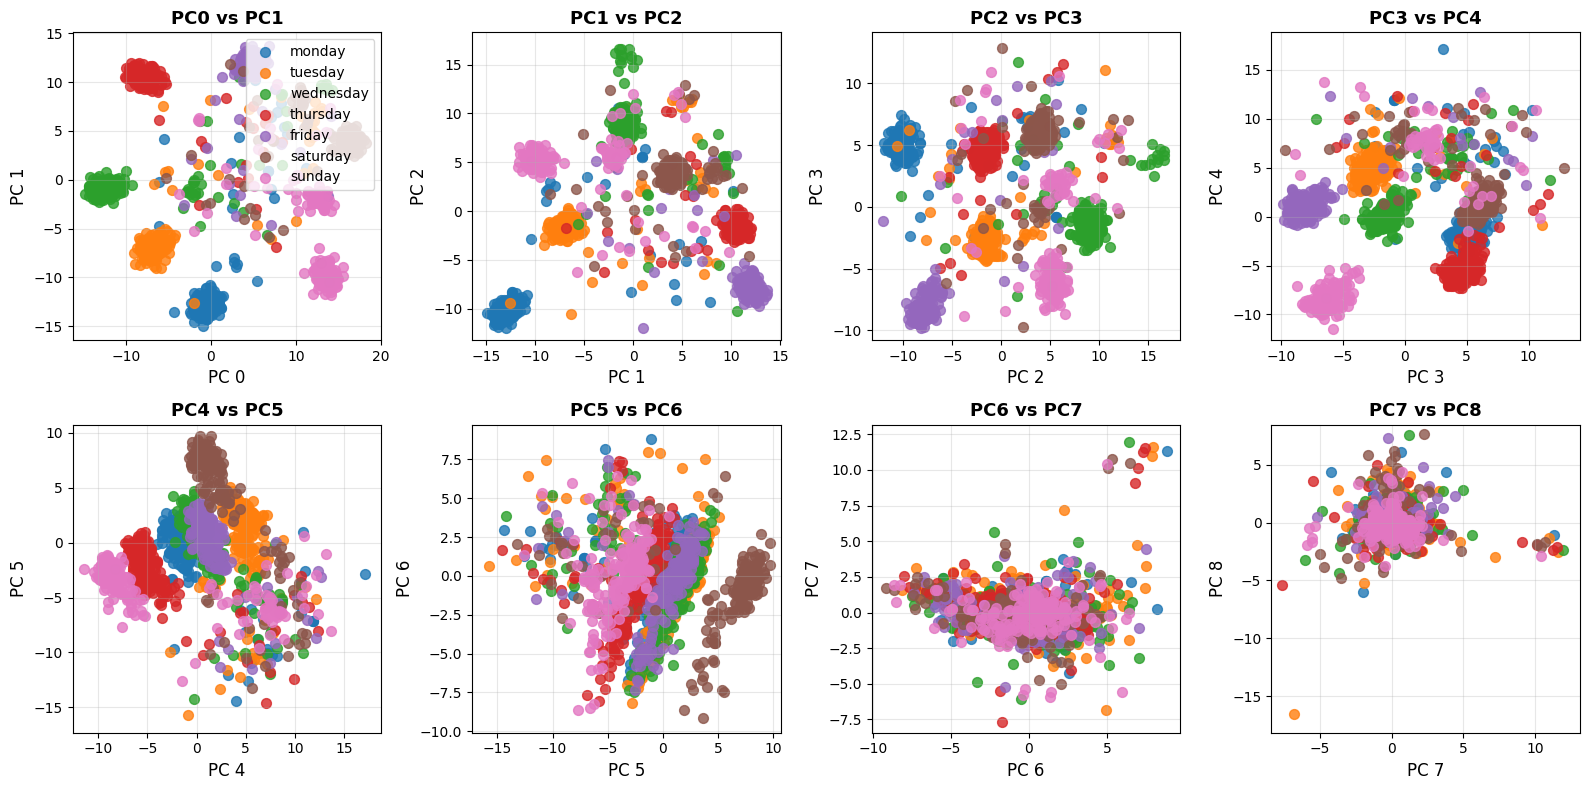

In [ ]:
plot_pca_2d(llm_enc_masked_bC, labels_enc_masked_bC)

### PCA of Sparse Codes (SAE encoder + Relu nonlinearity)

In [13]:
plot_pca_2d(codes_BS, labels)

NameError: name 'plot_pca_2d' is not defined

In [14]:
selected_codes_Bs = codes_BS[:, days_idxs]
plot_pca_2d(selected_codes_Bs, labels)

NameError: name 'codes_BS' is not defined

PCA Feature Splitting at it's best:
- Monday: PC4 high + PC1 high
- Thursday: PC4 lhigh + PC1 low

This is in PCA basis, actual SAE latents might be different. I suspect SAE latents have similar splitting going on...

In [15]:
# Going by norm, Can we capture all relevant SAE features? No.
codes_norm_B = np.linalg.norm(codes_BS, axis=-1)
plt.hist(codes_norm_B, bins=100, log=True);

NameError: name 'codes_BS' is not defined

In [16]:
mask = codes_norm_B > 90
codes_masked_bS = codes_BS[mask]
labels_codes_masked = [l for i, l in enumerate(labels) if mask[i]]
plot_pca_2d(codes_masked_bS, labels_codes_masked)

NameError: name 'codes_norm_B' is not defined

### PCA of projection of llm activations onto SAE selected feature decoder subspace

PCA transformed shape: (21001, 9)
Cumulative Explained Variance:
up to incl. PCA 0: 0.6939489841461182
up to incl. PCA 1: 0.7750770449638367
up to incl. PCA 2: 0.8276106715202332
up to incl. PCA 3: 0.8688693642616272
up to incl. PCA 4: 0.9081065058708191
up to incl. PCA 5: 0.9361844062805176
up to incl. PCA 6: 0.9620459675788879
up to incl. PCA 7: 0.9819444417953491
up to incl. PCA 8: 1.0


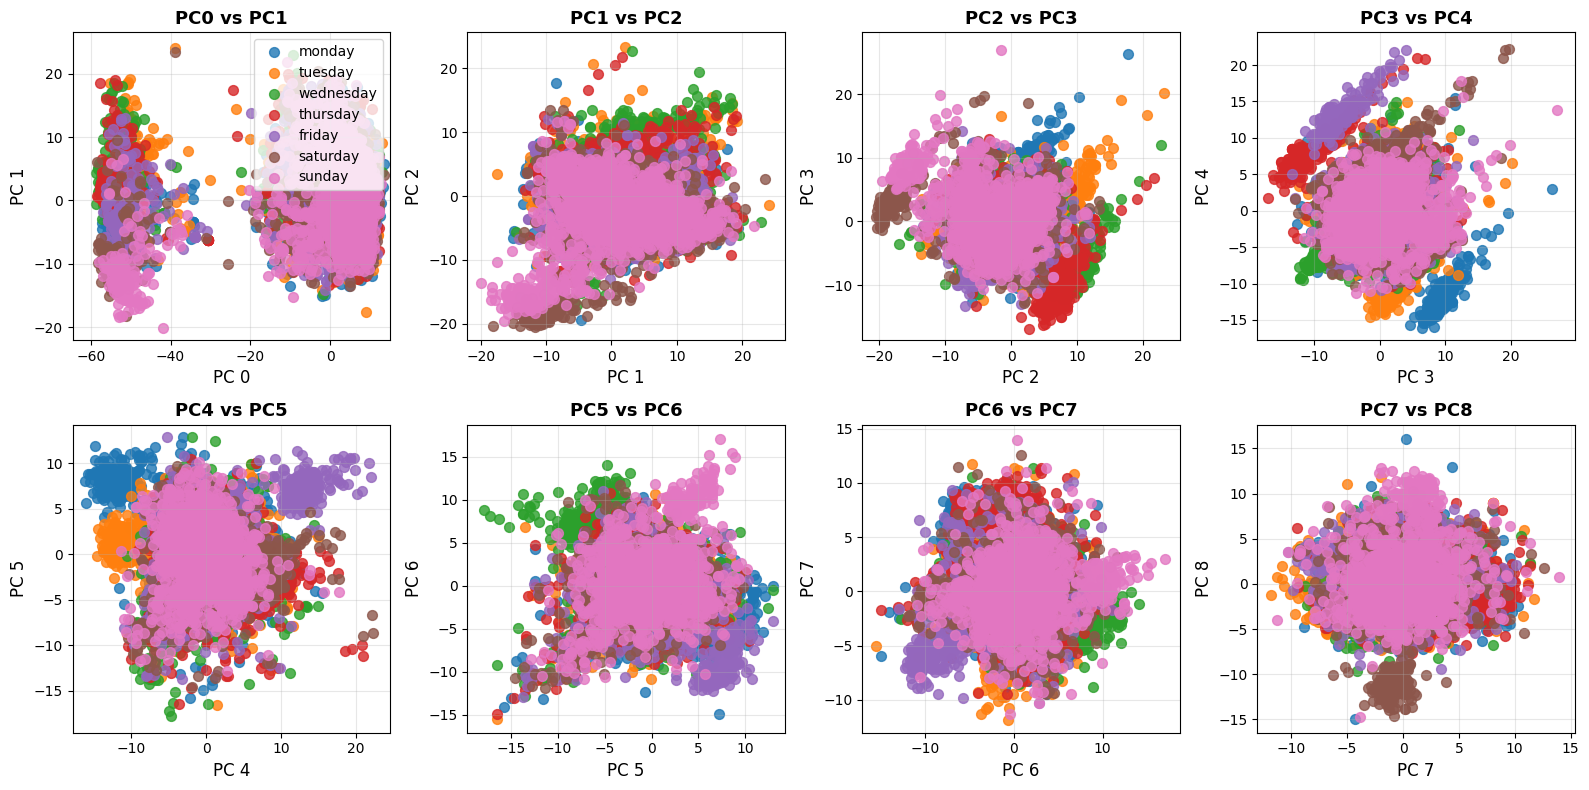

In [ ]:
_, _, Vh_dec = np.linalg.svd(W_dec_days_sD, full_matrices=False)
llm_dec_BC = llm_BD @ Vh_dec.T
plot_pca_2d(llm_dec_BC, labels)

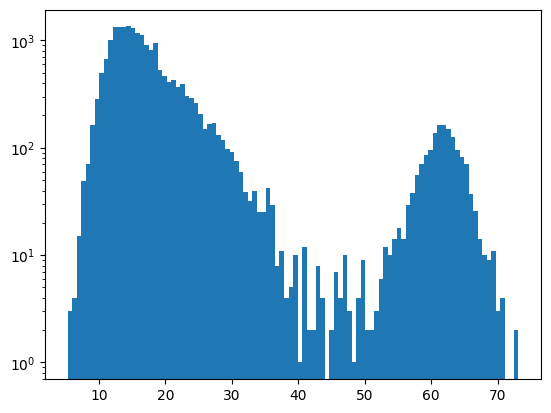

In [ ]:
llm_dec_BC_norms = np.linalg.norm(llm_dec_BC, axis=-1)
plt.hist(llm_dec_BC_norms, bins=100, log=True);

In [ ]:
# Filter out tomorrow / yesterday
relative_temporal_words = ["tomorrow", "yesterday"]
contains_temporal = lambda x: any([w in x.lower() for w in relative_temporal_words])
mask_relative_temporal = [not contains_temporal(t) for t in texts]

# Filter out small activations in subspace
mask = llm_dec_BC_norms > 50
mask_dec = mask & mask_relative_temporal

PCA transformed shape: (1553, 9)
Cumulative Explained Variance:
up to incl. PCA 0: 0.3563176691532135
up to incl. PCA 1: 0.6163771152496338
up to incl. PCA 2: 0.737018883228302
up to incl. PCA 3: 0.8211990594863892
up to incl. PCA 4: 0.8937855958938599
up to incl. PCA 5: 0.9578924775123596
up to incl. PCA 6: 0.9807418584823608
up to incl. PCA 7: 0.9951812624931335
up to incl. PCA 8: 1.0


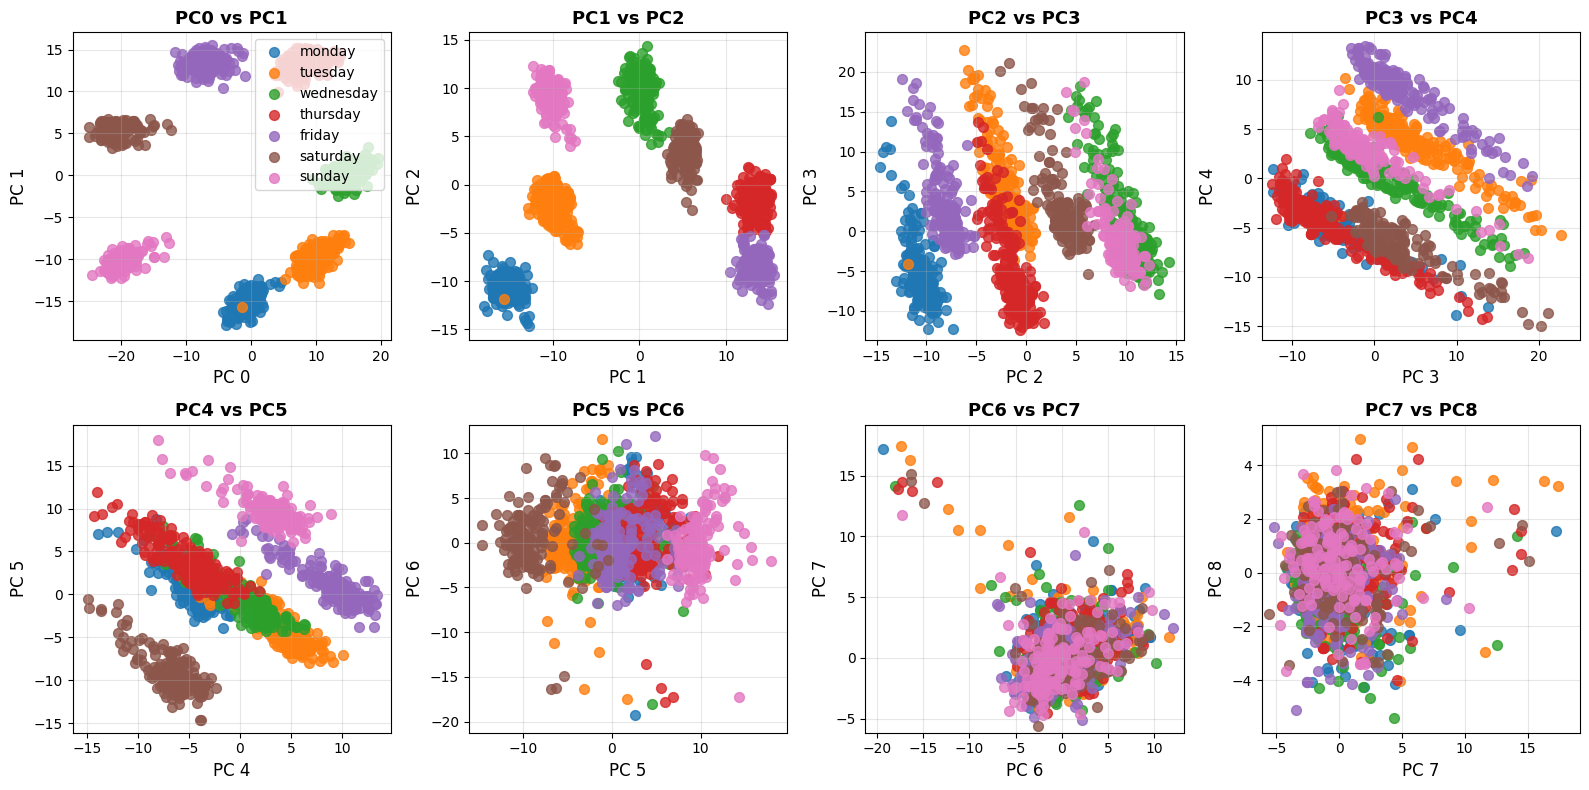

In [ ]:
# Plot PCA
llm_dec_masked_bC = llm_dec_BC[mask_dec]
labels_dec_masked_b = [l for l, m in zip(labels, mask_dec) if m]
plot_pca_2d(llm_dec_masked_bC, labels_dec_masked_b)

In [17]:
# Plot the first 3 PCA components in a 3D plot
texts_3d = [texts[i] for i, m in enumerate(mask_dec) if m]
plot_pca_3d(llm_dec_masked_bC, labels_dec_masked_b, texts_3d, pca_components=[0, 1, 2])

NameError: name 'mask_dec' is not defined

### Does the encoder bring any benefits? PCA on sparse reconstructions as in Engels et al.
--> No. Neither with nor without masking.

In [18]:
selected_codes_recons_BD = selected_codes_Bs @ W_enc_days_sD
plot_pca_2d(selected_codes_recons_BD[mask_dec], labels_dec_masked_b)

NameError: name 'selected_codes_Bs' is not defined

SAE Encoder + nonlinearity don't really help. Not really. Let's stick with the identified decoder vectors for now. What are the weekday centroids? Later: are the weekdays categorical or can we make them continuous?

## Plot effective dimensionality

In [19]:
plot_relative_energies(
    [llm_enc_BC, selected_codes_Bs, llm_dec_BC], 
    ["Encoder 'Reading' Subspace Projection", "Sparse Codes", "Decoder 'Writing' Subspace Projection"]
)

NameError: name 'llm_enc_BC' is not defined

Looks like the Encoder + Nonlinearity filter out the right dimensionality: Sudden drop after PCA component 5. Why is this lost by decoder?

## Weekday Cluster Centroids

In [20]:
from typing import Dict, List

def compute_centroids(act_BD: th.Tensor, labels: List, normalize: bool = True) -> Dict[str, List]:
    EPS = 1e-8
    unique_labels = list(dict.fromkeys(labels))

    centroids = {}
    for label in unique_labels:
        mask = [l == label for l in labels]
        centroid = act_BD[mask].mean(axis=0)

        if normalize:
            centroid = centroid / (np.linalg.norm(centroid) + EPS)

        centroids[label] = centroid

    return centroids

centroids = compute_centroids(llm_dec_masked_bC, labels_dec_masked_b)
cent_labels = list(centroids.keys())

centroids_Wd = np.stack([v for v in centroids.values()])
centroids_Wd.shape

NameError: name 'llm_dec_masked_bC' is not defined

Cumulative relative energy per PCA:
PCA 0: 0.8891515135765076
PCA 1: 0.9350824952125549
PCA 2: 0.9672164916992188
PCA 3: 0.9820061922073364
PCA 4: 0.9917405247688293
PCA 5: 0.9998712539672852
PCA 6: 1.0000001192092896



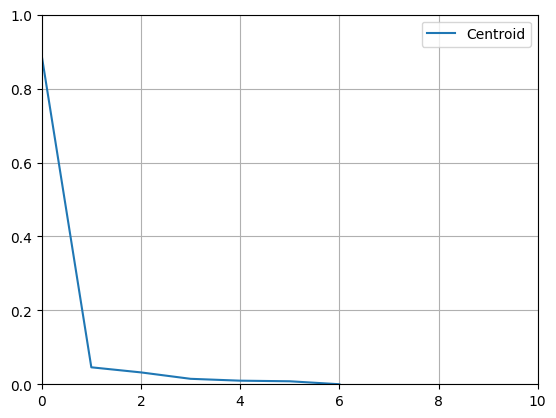

In [ ]:
plot_relative_energies([centroids_Wd], ["Centroid"])

PCA transformed shape: (7, 7)
Cumulative Explained Variance:
up to incl. PCA 0: 0.41498464345932007
up to incl. PCA 1: 0.7044398784637451
up to incl. PCA 2: 0.8378368616104126
up to incl. PCA 3: 0.9255202412605286
up to incl. PCA 4: 0.9988284111022949
up to incl. PCA 5: 1.0
up to incl. PCA 6: 1.0


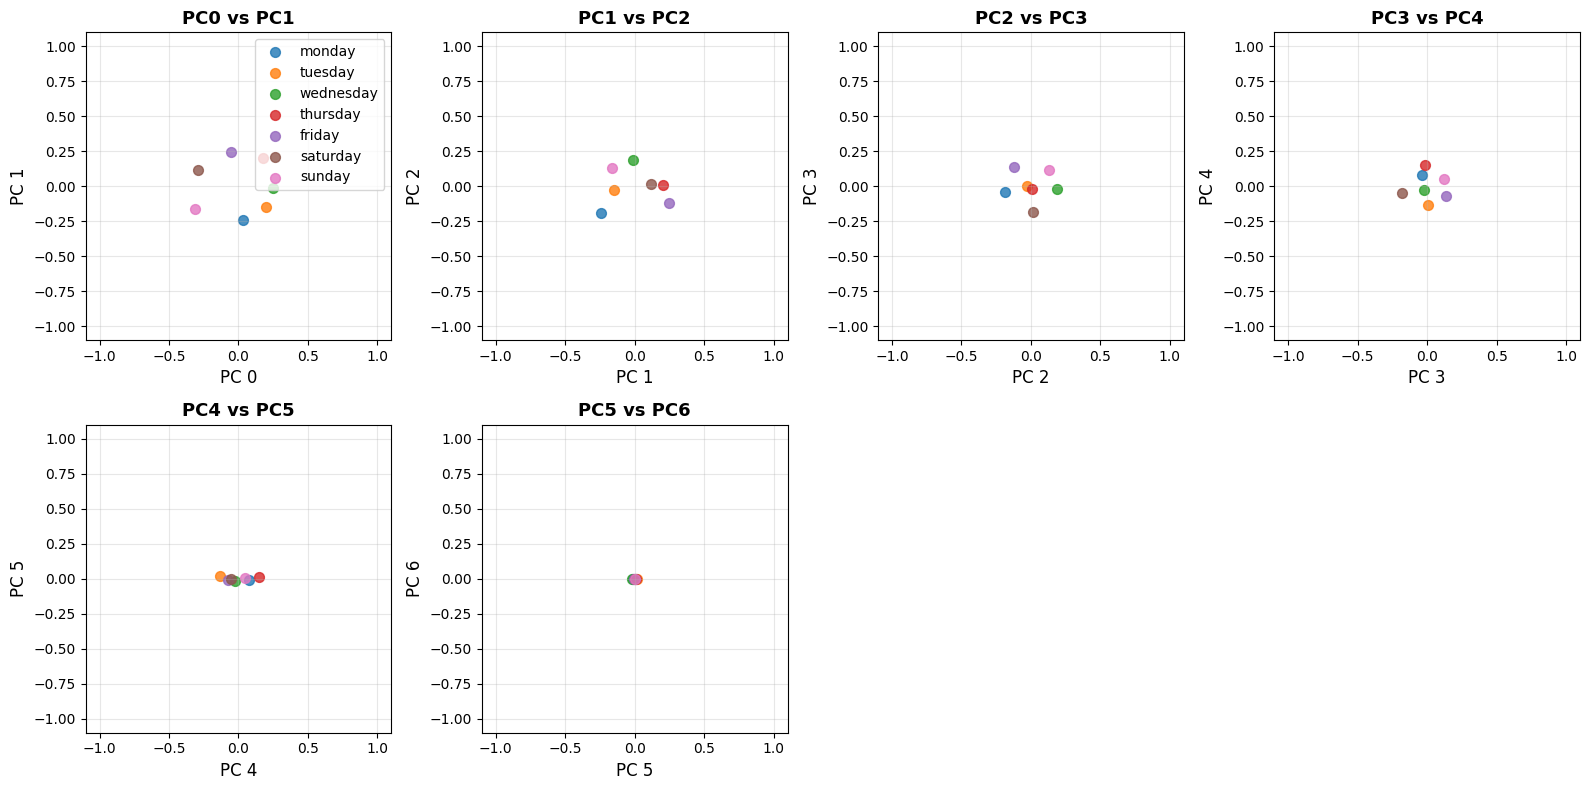

In [ ]:
pca_components_Cd = plot_pca_2d(centroids_Wd, cent_labels, num_pca_components=7, return_pca_components=True, min_ax_scale=1)

In [21]:
plot_pca_3d(centroids_Wd, cent_labels, pca_components=[3,4,5])

NameError: name 'plot_pca_3d' is not defined

Alright, I'm convinced that days of the week representations are effectively 6D (look at the explained variance per pca component printed above the plot!). How about structure? geometry? order?. Do we have an increment operator?

In [22]:
# We'll continue with a normlized version of the important components

cent_WC = centroids_Wd
cent_WC = cent_WC - cent_WC.mean(axis=0)
cent_WC = cent_WC / np.linalg.norm(cent_WC, axis=-1, keepdims=True)

print(cent_WC.shape)
cent_labels

NameError: name 'centroids_Wd' is not defined

### Cosine similarity heatmap

In [23]:
def plot_cosine_similarities(act_BD: np.ndarray, labels: List[str]) -> None:
    act_centered = act_BD - act_BD.mean(axis=0)
    act_normed_BD = act_centered / np.linalg.norm(act_centered, axis=-1, keepdims=True)
    sim_BB = act_normed_BD @ act_normed_BD.T

    plt.imshow(sim_BB)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)

plot_cosine_similarities(cent_WC, centroids.keys())
plt.title("Cosine similarities of cluster centroids")

NameError: name 'cent_WC' is not defined

Sidenote: Centering is necessary. Does that say someting about the shape?

## Increment operators:
## TLDR; fitting icrement operators from centroids alone is strongly underdetermined and gives misleading results

- fix1: use the full dataset, not centroids
    - even better: make a dataset where we have temporal transitions: constant prefix + day (instead of random occurences of days of the week in webtext)
    

In [126]:
A_current = cent_WC
A_next = np.concatenate([cent_WC[1:], [cent_WC[0]]], axis=0)

# A_current_WC @ T_CC = A_next_WC
# find matrix T that transforms the col vectors of A_next into col vectors of A_next

T = np.linalg.pinv(A_current) @ A_next

# Verify: T @ cent_WC should ≈ np.roll(cent_WC, -1, axis=1)
print("Reconstruction error:", np.linalg.norm(A_current @ T - A_next, 'fro'))

Reconstruction error: 0.009565816


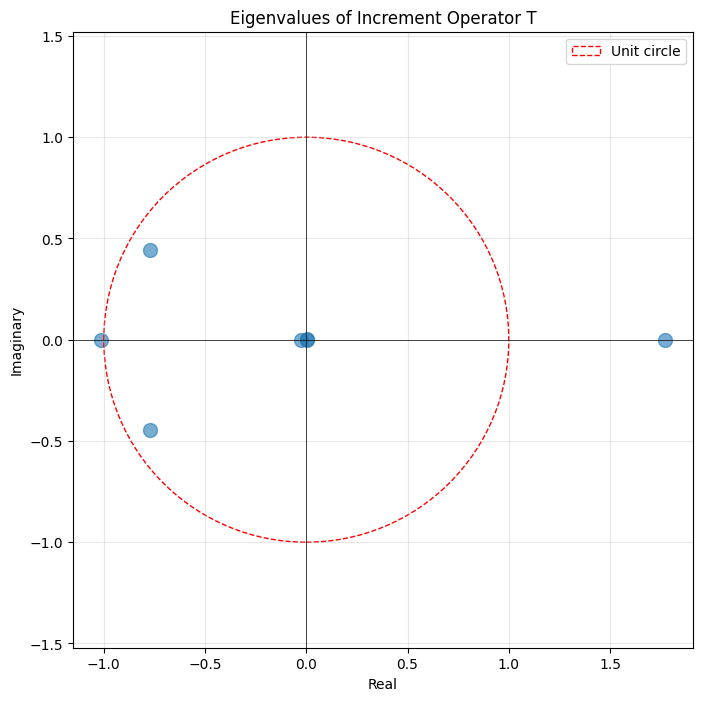

Eigenvalue magnitudes: [4.4213300e+00 4.4213300e+00 1.7700046e+00 8.9275408e-01 8.9275408e-01
 1.0134821e+00 2.5812661e-02 4.2980197e-03 4.2980197e-03]
Eigenvalue phases (in units of 2π): [ 0.2354465  -0.2354465   0.          0.4169187  -0.4169187   0.5
  0.5         0.15532582 -0.15532582]


In [127]:
# Eigendecomposition of Increment operator
eigenvalues, eigenvectors = np.linalg.eig(T)

# Plot eigenvalues in complex plane
plt.figure(figsize=(8, 8))
plt.scatter(eigenvalues.real[2:], eigenvalues.imag[2:], s=100, alpha=0.6)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--', label='Unit circle')
plt.gca().add_patch(circle)
plt.axis('equal')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.title('Eigenvalues of Increment Operator T')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# For a 7-day cycle, expect eigenvalues near e^(2πi k/7) for k=0,1,2,...,6
print("Eigenvalue magnitudes:", np.abs(eigenvalues))
angles = np.angle(eigenvalues) / (2*np.pi)
print("Eigenvalue phases (in units of 2π):", angles)

Looks like three orthogonal rotations around one axis!

In [128]:
T.shape

(9, 9)

In [129]:
cent_WC.shape, eigenvectors.shape

((7, 9), (9, 9))

In [130]:
eigenvectors[6].imag

array([-4.2516785e-06,  4.2516785e-06,  0.0000000e+00,  9.1149654e-05,
       -9.1149654e-05,  0.0000000e+00,  0.0000000e+00,  1.0193280e-02,
       -1.0193280e-02], dtype=float32)

Eigvalues: [ 0.40373352+4.4028578e+00j  0.40373352-4.4028578e+00j
  1.7700046 +0.0000000e+00j -0.77385354+4.4515213e-01j
 -0.77385354-4.4515213e-01j -1.0134821 +0.0000000e+00j
 -0.02581266+0.0000000e+00j  0.00240856+3.5597468e-03j
  0.00240856-3.5597468e-03j]
Eigvectors: [[-9.84499872e-01+0.0000000e+00j -9.84499872e-01-0.0000000e+00j
   9.84473765e-01+0.0000000e+00j -9.84302104e-01+0.0000000e+00j
  -9.84302104e-01-0.0000000e+00j  9.84523058e-01+0.0000000e+00j
  -9.84286845e-01+0.0000000e+00j  9.84138310e-01+0.0000000e+00j
   9.84138310e-01-0.0000000e+00j]
 [-3.13860849e-02-8.9223849e-06j -3.13860849e-02+8.9223849e-06j
   3.13160978e-02+0.0000000e+00j -3.17322835e-02+7.3460353e-05j
  -3.17322835e-02-7.3460353e-05j  3.14076766e-02+0.0000000e+00j
  -3.14462148e-02+0.0000000e+00j  3.16270031e-02-8.3868287e-04j
   3.16270031e-02+8.3868287e-04j]
 [ 7.09544122e-02-6.4180545e-05j  7.09544122e-02+6.4180545e-05j
  -7.10162893e-02+0.0000000e+00j  7.14865178e-02-1.6823820e-04j
   7.14865178e-02+1.

(array([[-0.16444783, -0.05009384],
        [ 0.5278754 ,  0.42772013],
        [ 0.46982083,  0.03550828],
        [-0.1698559 , -0.33456478],
        [-0.2718882 ,  0.38449177],
        [-0.07598582, -0.40095255],
        [-0.19342679,  0.02826761]], dtype=float32),
 array([[-0.1816819 ,  0.06120257],
        [ 0.51604   , -0.41324207],
        [ 0.4847895 , -0.01913598],
        [-0.1565027 ,  0.33499357],
        [-0.2755696 , -0.4052275 ],
        [-0.09846829,  0.38673323],
        [-0.16957964, -0.03105096]], dtype=float32),
 array([[ 0.15423   ,  0.0605901 ],
        [-0.5343654 , -0.41485825],
        [-0.46090648, -0.0210764 ],
        [ 0.1779932 ,  0.3340967 ],
        [ 0.269952  , -0.40390244],
        [ 0.06148573,  0.38848773],
        [ 0.20786735, -0.02984866]], dtype=float32),
 array([[ 0.21501365, -0.06868235],
        [-0.4822553 ,  0.40396142],
        [-0.5024253 ,  0.00905618],
        [ 0.12844592, -0.33419943],
        [ 0.27476317,  0.41881332],
        [ 0.1

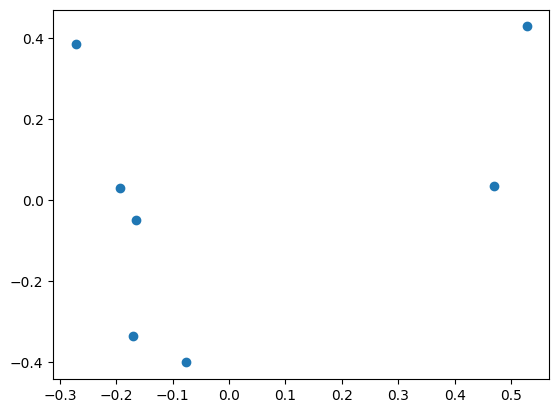

In [131]:
eigenvalues, eigenvectors = np.linalg.eig(T)
print(f'Eigvalues: {eigenvalues}')
print(f'Eigvectors: {eigenvectors}')

def eigpair_to_real_plane(v, tol=1e-3):
    a = v.real
    b = v.imag

    if np.linalg.norm(b) < tol * np.linalg.norm(a):
        raise ValueError("Eigenvector is numerically real; no rotation plane.")

    # Orthonormalize
    a = a / np.linalg.norm(a)
    b = b - a * np.dot(a, b)
    b = b / np.linalg.norm(b)

    return np.stack([a, b], axis=1)


rotation_axis_C = eigenvectors[6]
# plane0_C2 = eigpair_to_real_plane(eigenvectors[0])
plane1_C2 = eigpair_to_real_plane(eigenvectors[2])
plane2_C2 = eigpair_to_real_plane(eigenvectors[4])

cent_p1proj_W2 = cent_WC @ plane1_C2
cent_p2proj_W2 = cent_WC @ plane2_C2
print(f" projection {cent_p2proj_W2}")
plt.scatter(cent_p1proj_W2[:, 0], cent_p1proj_W2[:, 1])


# Conjugate should yield the same projection?
# plane0_C2 = eigpair_to_real_plane(eigenvectors[1])
plane1c_C2 = eigpair_to_real_plane(eigenvectors[3])
plane2c_C2 = eigpair_to_real_plane(eigenvectors[5])

cent_p1cproj_W2 = cent_WC @ plane1c_C2
cent_p2cproj_W2 = cent_WC @ plane2c_C2

cent_p1proj_W2, cent_p2proj_W2, cent_p1cproj_W2, cent_p2cproj_W2

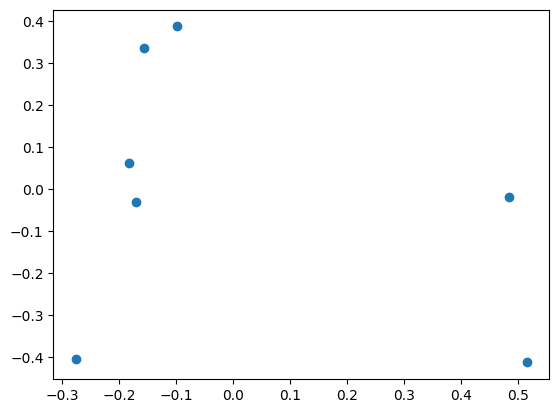

In [132]:
plt.scatter(cent_p2proj_W2[:, 0], cent_p2proj_W2[:, 1])

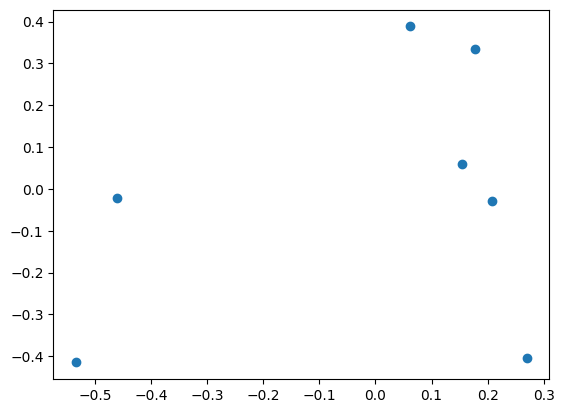

In [133]:
plt.scatter(cent_p1cproj_W2[:, 0], cent_p1cproj_W2[:, 1])

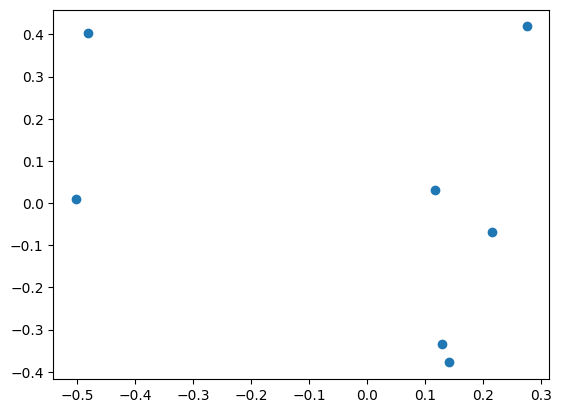

In [134]:
plt.scatter(cent_p2cproj_W2[:, 0], cent_p2cproj_W2[:, 1], )

In [96]:
eigenvectors

array([[ 0.9730617 +0.0000000e+00j,  0.9730617 -0.0000000e+00j,
         0.9729171 +0.0000000e+00j,  0.9729171 -0.0000000e+00j,
        -0.96566546+0.0000000e+00j, -0.96566546-0.0000000e+00j,
         0.97251886+0.0000000e+00j,  0.5656752 +0.0000000e+00j,
         0.9464181 +0.0000000e+00j],
       [-0.03434412+1.6785592e-05j, -0.03434412-1.6785592e-05j,
        -0.03420347+9.4991073e-04j, -0.03420347-9.4991073e-04j,
         0.04052428+5.0316527e-03j,  0.04052428-5.0316527e-03j,
        -0.03365258+0.0000000e+00j, -0.02594151+0.0000000e+00j,
        -0.04906338+0.0000000e+00j],
       [ 0.1357624 -7.1494927e-05j,  0.1357624 +7.1494927e-05j,
         0.13520251-1.5207623e-03j,  0.13520251+1.5207623e-03j,
        -0.14720011-1.1207557e-02j, -0.14720011+1.1207557e-02j,
         0.13761231+0.0000000e+00j,  0.0738524 +0.0000000e+00j,
         0.2265937 +0.0000000e+00j],
       [-0.13232125+3.1988890e-05j, -0.13232125-3.1988890e-05j,
        -0.13282394+1.1769158e-03j, -0.13282394-1.1769158

In [97]:
plane0_C2

array([[-0.31098646,  0.00231763],
       [-0.31098646, -0.00231763],
       [-0.30971295,  0.13115665],
       [-0.30971295, -0.13115665],
       [ 0.36694795,  0.69473344],
       [ 0.36694795, -0.69473344],
       [-0.30472463,  0.        ],
       [-0.23490077,  0.        ],
       [-0.4442696 ,  0.        ]], dtype=float32)


# augment with early/late morning afternoon evening, night